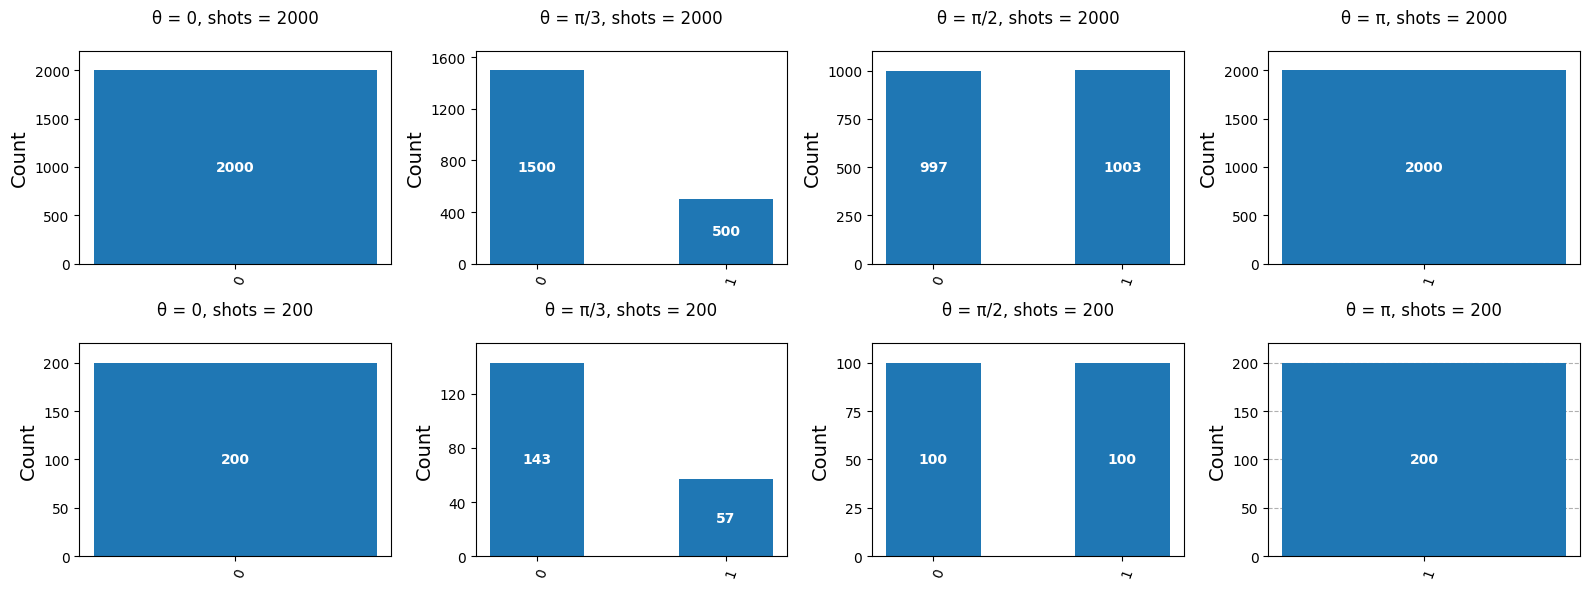


================ TABLA DE RESULTADOS ================

shots | theta | counts | p0_theo | p0_exp | sigma0 | z0 | p1_theo | p1_exp | sigma1 | z1
--------------------------------------------------------------------------------------------------------------
 2000 |   0   | {'0': 2000} | 1.0000 | 1.0000 | 0.0000 | 0.00 | 0.0000 | 0.0000 | 0.0000 | 0.00
 2000 |  π/3  | {'0': 1500, '1': 500} | 0.7500 | 0.7500 | 0.0097 | 0.00 | 0.2500 | 0.2500 | 0.0097 | 0.00
 2000 |  π/2  | {'1': 1003, '0': 997} | 0.5000 | 0.4985 | 0.0112 | 0.13 | 0.5000 | 0.5015 | 0.0112 | 0.13
 2000 |   π   | {'1': 2000} | 0.0000 | 0.0000 | 0.0000 | 0.00 | 1.0000 | 1.0000 | 0.0000 | 0.00
  200 |   0   | {'0': 200} | 1.0000 | 1.0000 | 0.0000 | 0.00 | 0.0000 | 0.0000 | 0.0000 | 0.00
  200 |  π/3  | {'0': 143, '1': 57} | 0.7500 | 0.7150 | 0.0319 | 1.10 | 0.2500 | 0.2850 | 0.0319 | 1.10
  200 |  π/2  | {'0': 100, '1': 100} | 0.5000 | 0.5000 | 0.0354 | 0.00 | 0.5000 | 0.5000 | 0.0354 | 0.00
  200 |   π   | {'1': 200} | 0.0000 

In [2]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
#tal vez haga falta añadir la libreria pylatexenc
# ---------------------------------------
# CONFIGURACIÓN
# ---------------------------------------
# Definir pi numérico y sus representaciones en texto
pi_numeric = np.pi
thetas = [0, np.pi/3, np.pi/2, np.pi] #definimmos todos los angulos que se piden en el guion

# Diccionario para mapear valores numéricos a representaciónes en π util para una grafica mas clara
theta_labels = {
    0: "0",
    np.pi/3: "π/3",
    np.pi/2: "π/2",
    np.pi: "π"
}

#realizaremos 2 medadas, una con 2000 shots y otra con 200 shots para comparar la precisión de los resultados
shots_list = [2000, 200]

sim = AerSimulator()

# ---------------------------------------
# FUNCIÓN PARA EJECUTAR EL EXPERIMENTO
# ---------------------------------------


def run_experiment(theta, shots):
    qc = QuantumCircuit(1, 1) # Circuito con 1 qubit y 1 bit clásico
    qc.ry(theta, 0)  # Aplicar la puerta de rotación RY con el ángulo theta al qubit 0
    qc.measure(0, 0) # Medir el qubit 0 y almacenar el resultado en el bit clásico 0

    result = sim.run(qc, shots=shots).result()
    counts = result.get_counts()

    # Probabilidades experimentales
    p0_exp = counts.get('0', 0) / shots
    p1_exp = counts.get('1', 0) / shots

    # Probabilidades teóricas
    p0_theo = (np.cos(theta/2))**2
    p1_theo = (np.sin(theta/2))**2

    # Incertidumbres
    sigma0 = np.sqrt(p0_exp*(1 - p0_exp)/shots)
    sigma1 = np.sqrt(p1_exp*(1 - p1_exp)/shots)

    # z-scores
    z0 = abs(p0_exp - p0_theo) / sigma0 if sigma0 > 0 else 0
    z1 = abs(p1_exp - p1_theo) / sigma1 if sigma1 > 0 else 0

    return counts, p0_exp, p1_exp, p0_theo, p1_theo, sigma0, sigma1, z0, z1

# ---------------------------------------
# PLOTEO DE TODOS LOS HISTOGRAMAS
# ---------------------------------------
fig, axes = plt.subplots(len(shots_list), len(thetas), figsize=(16, 6))

tabla_resultados = [] #Creamos una lista vacía que será nustra tabla, le daremos el mismo formato que la requerida para el guion.

for i, shots in enumerate(shots_list):
    for j, theta in enumerate(thetas):

        (counts, p0_exp, p1_exp, p0_theo, p1_theo,
         sigma0, sigma1, z0, z1) = run_experiment(theta, shots)

        # Guardamos en tabla
        tabla_resultados.append([
            shots, theta, counts,
            p0_theo, p0_exp, sigma0, z0,
            p1_theo, p1_exp, sigma1, z1
        ])

        # Dibujar histograma
        ax = axes[i, j]
        plot_histogram(counts, ax=ax, bar_labels=False)
        theta_label = theta_labels.get(theta, f"{theta:.2f}")
        ax.set_title(f"θ = {theta_label}, shots = {shots}", color='black', pad=20)

        # Agregar el número de repeticiones dentro de cada barra
        for bar in ax.patches:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, height/2, f'{int(height)}', 
                    ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

# ---------------------------------------
# TABLA DE RESULTADOS
# ---------------------------------------
print("\n================ TABLA DE RESULTADOS ================\n")
print("shots | theta | counts | p0_theo | p0_exp | sigma0 | z0 | p1_theo | p1_exp | sigma1 | z1")
print("-"*110)

for row in tabla_resultados:
    theta_label = theta_labels.get(row[1], f"{row[1]:.2f}")
    print(f"{row[0]:5d} | {theta_label:^5s} | {row[2]} | "
          f"{row[3]:.4f} | {row[4]:.4f} | {row[5]:.4f} | {row[6]:.2f} | "
          f"{row[7]:.4f} | {row[8]:.4f} | {row[9]:.4f} | {row[10]:.2f}")


#Imagen del circuito para 1 qubit y rotacion sobre el eje Y con theta = pi/2

#volvemos a craer el circuito para mostrarlo, con solo una de las posibles rotaciones.
qc = QuantumCircuit(1, 1)
qc.ry(np.pi/2, 0)
qc.measure(0, 0)
qc.draw(output="mpl")
plt.show()


Cuadro 2: Resultados experimentales simulados para el estado de Bell |Φ+>

Base | Shots | P_exp(00) | P_exp(01) | P_exp(10) | P_exp(11) | <O ⊗ O>_exp | <O ⊗ O>_teo | z
--------------------------------------------------------------------------------------------
  ZZ |   200 | 0.445     | 0.000     | 0.000     | 0.555     | 1.000        | 1.0           | 0.00
  XX |   200 | 0.495     | 0.000     | 0.000     | 0.505     | 1.000        | 1.0           | 0.00


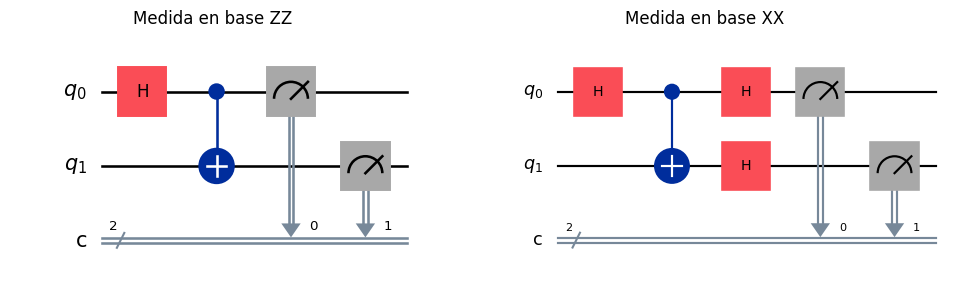

In [3]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
#tal vez haga falta añadir la libreria pylatexenc

sim = AerSimulator()
shots = 200

# ==================================================
# FUNCIONES AUXILIARES
# ==================================================


#esta función asigna un valor de correlación de +1 a los resultados "00" y "11", y -1 a "01" y "10". 
# Esto es porque en el estado de Bell |Φ+>, los resultados "00" y "11" son correlacionados positivamente, mientras que "01" y "10" son correlacionados negativamente.

def correl_value(bitstring):

    return +1 if bitstring in ["00", "11"] else -1

def z_score(exp, probs):
    p_plus = probs.get("00", 0) + probs.get("11", 0)
    sigma = 2 * np.sqrt(p_plus * (1 - p_plus) / shots)
    z = abs(exp - 1) / sigma if sigma != 0 else 0
    return sigma, z

def build_circuit(basis):#constrye un circuito cuantico de 2 qbits y 2 bits clasicos
    qc = QuantumCircuit(2, 2)

    #  Aplicamos las puertas para crear el Estado de Bell |Φ+>
    qc.h(0)
    qc.cx(0, 1)

    # Cambio de base si es XX
    if basis == "XX":
        qc.h(0)
        qc.h(1)

    qc.measure([0, 1], [0, 1])
    return qc

def run_circuit(basis):
    qc = build_circuit(basis)
    result = sim.run(qc, shots=shots).result()
    counts = result.get_counts()

    probs = {k: counts.get(k, 0) / shots for k in ["00", "01", "10", "11"]}
    exp = sum(correl_value(s) * counts.get(s, 0) for s in counts) / shots
    sigma, z = z_score(exp, probs)

    return qc, probs, exp, sigma, z

# ==================================================
# EJECUCIÓN PARA ZZ y XX
# ==================================================

results = {}
circuits = {}

#corremos 2 veces el circuito, una para cada base de medida (ZZ y XX).
for basis in ["ZZ", "XX"]:
    qc, probs, exp, sigma, z = run_circuit(basis)
    circuits[basis] = qc
    results[basis] = {
        "probs": probs,
        "exp": exp,
        "theo": 1,
        "z": z
    }

# ==================================================
# TABLA FINAL
# ==================================================

print("\nCuadro 2: Resultados experimentales simulados para el estado de Bell |Φ+>\n")

header = (
    "Base | Shots | P_exp(00) | P_exp(01) | P_exp(10) | P_exp(11) | "
    "<O ⊗ O>_exp | <O ⊗ O>_teo | z"
)
print(header)
print("-" * len(header))

for basis in ["ZZ", "XX"]:
    r = results[basis]
    p = r["probs"]
    print(
        f"{basis:>4} | {shots:>5} | "
        f"{p['00']:.3f}     | {p['01']:.3f}     | "
        f"{p['10']:.3f}     | {p['11']:.3f}     | "
        f"{r['exp']:.3f}        | {r['theo']:.1f}           | {r['z']:.2f}"
    )

# ==================================================
# VISUALIZACIÓN DE LOS CIRCUITOS
# ==================================================

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

circuits["ZZ"].draw(output="mpl", ax=axes[0], style={'usepylatex': False})
axes[0].set_title("Medida en base ZZ")

circuits["XX"].draw(output="mpl", ax=axes[1], style={'usepylatex': False})
axes[1].set_title("Medida en base XX")

plt.tight_layout()
plt.show()
